# Tutorial: Building a `CEModel` from Scratch

This is a **guided, hands-on** tutorial, not a demo — most code cells below
are partially blank with `# TODO: ...` markers for you to fill in. Each TODO
is preceded by a markdown cell explaining what you're building and followed
by one explaining what to look for after running it (expected shape,
expected trend, what a wrong answer would look like).

Every TODO has a **worked solution** in the Appendix at the end of the
notebook — try each cell yourself first before looking. Solutions are kept
out of the main flow on purpose so you can't see them without scrolling past
the whole tutorial.

No PyBullet, no `CoopGrasping-v6_dataset.pkl`, no GPU required — everything
here runs on CPU in well under a minute. See also
`07_synthetic_data_and_applications.ipynb` for a deeper look at the raw data
shapes and applications this framework fits, and `general/README.md` for the
full API reference.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset as TorchDataset

from conditional_embedding_model.general import (
    EncoderConfig, ScorerConfig, CEModelConfig, build_model,
    ContrastiveBCELoss, Trainer,
)
from conditional_embedding_model.general.examples.toy import make_toy_data

torch.manual_seed(0)
np.random.seed(0)

## Step 1 — Build a config from scratch

A `CEModel` is never subclassed directly; it's assembled from three small
dataclasses:

- `EncoderConfig(name, params)` — `name` is a string key into
  `ENCODER_REGISTRY` (built-ins: `legacy_v4_center`, `legacy_v4_context`,
  `legacy_v5_center`, `legacy_v5_context`, `mlp`); `params` are the kwargs
  passed to that encoder class's `__init__`. This is what makes an
  architecture swap a one-line config edit instead of a subclass.
- `ScorerConfig(name, params)` — same idea for `SCORER_REGISTRY`
  (`cosine_temperature`, `dot_product`, `bilinear`, `mlp_scorer`,
  `multi_relation`). Defaults to `cosine_temperature` at `temperature=0.07`.
- `CEModelConfig(embedding_dim, center_encoder, context_encoder, scorer)` —
  the top-level config `build_model()` consumes. `embedding_dim` must match
  what the chosen center/context encoders actually output (`CEModel`
  asserts `center_encoder.output_dim == context_encoder.output_dim` at
  construction time — a mismatch there is a config bug, not a shape you
  need to hand-verify).

**TODO:** construct an `EncoderConfig` for the `mlp` encoder (used for both
center and context — same `params` dict is fine for both), a
`ScorerConfig` for `cosine_temperature`, and wrap them in a `CEModelConfig`.
Use `obs_dim=32` as the encoder's `input_dim`, `hidden_dims=(64, 64)`, and
`embedding_dim=8` throughout (`CEModelConfig.embedding_dim` and each
encoder's `output_dim` param).

In [2]:
obs_dim = 32
embedding_dim = 8

# TODO: build `encoder_params` (dict): input_dim=obs_dim, output_dim=embedding_dim,
#       hidden_dims=(64, 64), activation="relu", layer_norm=True
encoder_params = ...

# TODO: build `center_encoder_cfg` and `context_encoder_cfg` as EncoderConfig(name="mlp", params=...)
center_encoder_cfg = ...
context_encoder_cfg = ...

# TODO: build `scorer_cfg` as ScorerConfig(name="cosine_temperature", params={"temperature": 0.07})
scorer_cfg = ...

# TODO: build `model_config` as a CEModelConfig combining the three configs above
model_config = ...

# Fill in the TODOs above, then run this cell -- if model_config is still `...`,
# uncomment the next line to see the AttributeError this step is meant to avoid.
# model_config.to_dict()

**What to look for:** once filled in, `model_config.to_dict()` should
print a nested dict with `embedding_dim: 8`, and `center_encoder`/
`context_encoder` each showing `{"name": "mlp", "params": {...}}` with
`input_dim: 32`, `output_dim: 8`. The Appendix "Step 1 solution" cell below
shows this working end to end — this cell above is intentionally left with
`...` placeholders so it runs without error either way (unfilled or filled),
rather than raising until you complete it and inspect it yourself.

## Step 2 — Build the model and check output shapes

`build_model(config)` resolves the registry names in your config into actual
`nn.Module` instances and wires them into a `CEModel`. The two methods worth
checking immediately after building any new config are `embed_center` and
`embed_context` — get their output shapes wrong and every downstream loss/
metric computation will silently broadcast into garbage instead of erroring.

**TODO:** call `build_model(model_config)`, then run one center batch
(`[B, obs_dim]`) through `model.embed_center` and one context batch
(`[B, K, obs_dim]`) through `model.embed_context`. Assert both outputs' last
dimension equals `embedding_dim`.

In [3]:
B, K = 4, 16

# TODO: build the model
model = ...

fake_center = {"x": torch.randn(B, obs_dim)}
fake_context = {"x": torch.randn(B, K, obs_dim)}

# TODO: embed both and store as `center_emb`, `context_emb`
center_emb = ...
context_emb = ...

# Uncomment once filled in:
# print("center_emb:", tuple(center_emb.shape))
# print("context_emb:", tuple(context_emb.shape))
# assert center_emb.shape == (B, embedding_dim)
# assert context_emb.shape == (B, K, embedding_dim)

**What to look for:** `center_emb` should be `(4, 8)`, `context_emb` should
be `(4, 16, 8)` — batch dimensions unchanged, trailing dimension collapsed
to `embedding_dim`. A wrong answer here looks like an assertion error citing
a shape like `(4, 32)` (forgot to build the model / embed, still looking at
raw input) or `(4, 16, 16)` (mixed up `embedding_dim` and `K` somewhere in a
custom encoder). See the Appendix for this working end to end with real
output.

## Step 3 — Synthetic data and the batch contract

`Trainer` doesn't know anything about grasping, images, or any specific
domain — it only knows the **batch contract**:
`((center_inputs: dict, context_inputs: dict), label: Tensor[B,K], mask: Tensor[B,K])`.
Any `DataLoader` whose `collate_fn` produces that 3-tuple works with
`Trainer.fit`/`evaluate` unmodified. (For the legacy `batchify_wrapper`
5-tuple output specifically, `general.training.LegacyBatchAdapter` builds
this adapter for you — not needed here since we're using fresh synthetic
data, not the legacy dataloader.)

We reuse `make_toy_data` (`general/examples/toy.py`) for synthetic data with
a known planted affinity — see `07_synthetic_data_and_applications.ipynb`
for a full visual tour of what this data looks like.

**TODO:** call `make_toy_data(n_centers=2048, K=K, latent_dim=4, obs_dim=obs_dim, noise=0.1, n_pos=2, seed=0)`,
wrap the returned `train`/`val` dicts in the `_ToyDataset`/`_collate` helpers
below (already written — the batch-contract shape is what to focus on here,
not dataset boilerplate), and build `train_loader`/`val_loader`.

In [4]:
class _ToyDataset(TorchDataset):
    def __init__(self, data):
        self.center_x = data["center_x"]
        self.context_x = data["context_x"]
        self.label = data["label"]
        self.mask = data["mask"]

    def __len__(self):
        return self.center_x.shape[0]

    def __getitem__(self, i):
        return self.center_x[i], self.context_x[i], self.label[i], self.mask[i]


def _collate(batch):
    center_x = torch.stack([b[0] for b in batch])
    context_x = torch.stack([b[1] for b in batch])
    label = torch.stack([b[2] for b in batch])
    mask = torch.stack([b[3] for b in batch])
    return (({"x": center_x}, {"x": context_x}), label, mask)


# TODO: call make_toy_data(...) -> train_data, val_data, W
train_data, val_data, W = ..., ..., ...

# TODO: wrap in DataLoader(_ToyDataset(...), batch_size=128, shuffle=..., collate_fn=_collate)
#       (shuffle=True for train, shuffle=False for val)
train_loader = ...
val_loader = ...

# Uncomment once filled in:
# (center_inputs, context_inputs), label, mask = next(iter(train_loader))
# print("center_inputs['x']:", tuple(center_inputs["x"].shape))
# print("context_inputs['x']:", tuple(context_inputs["x"].shape))
# print("label:", tuple(label.shape), "mask:", tuple(mask.shape))

**What to look for:** `center_inputs['x']` should be `(128, 32)`,
`context_inputs['x']` should be `(128, 16, 32)`, and `label`/`mask` should
both be `(128, 16)` — matching `context_inputs`'s first two dims exactly,
since `label`/`mask` mark which of the `K` padded slots are positive/real
per center. If `label.shape != mask.shape` or either doesn't match
`context_inputs["x"].shape[:2]`, `Trainer` will error inside `ContrastiveBCELoss`
the moment you call `fit` — better to catch it here.

## Step 4 — Train

`Trainer(model, loss, optimizer, *, device=..., ...)` runs the standard
loop: forward → loss → backward → optimizer step per batch, with an
optional validation pass and scheduler step per epoch. `device` defaults to
`"cuda:0"` in the class signature — **pass `device="cpu"` explicitly**, this
tutorial has no GPU dependency.

**TODO:** build a `ContrastiveBCELoss(normalization="valid_pairs")`, an
`Adam` optimizer over `model.parameters()` (`lr=1e-3`), a `Trainer` with
`device="cpu"`, and call `trainer.fit(train_loader, val_loader=val_loader, epochs=15)`.

In [5]:
# TODO: loss_fn = ContrastiveBCELoss(normalization="valid_pairs")
loss_fn = ...

# TODO: optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = ...

# TODO: trainer = Trainer(model, loss_fn, optimizer, device="cpu", amp=False)
trainer = ...

# TODO: history = trainer.fit(train_loader, val_loader=val_loader, epochs=15)
history = ...

# Uncomment once filled in:
# print("train_loss:", [round(x, 4) for x in history["train_loss"]])
# print("val_loss:  ", [round(x, 4) for x in history["val_loss"]])

**What to look for:** `history["train_loss"]` should be a list of 15
floats that trends downward overall (it doesn't need to be monotonic epoch
to epoch) — roughly halving from the first to the last entry is typical for
this synthetic setup. **No `nan` or `inf` anywhere in either list** — if you
see one, the most common cause at this stage is `device` mismatch (a
`Trainer` accidentally left at the `"cuda:0"` default on a machine with no
GPU raises immediately rather than producing `nan`, so a `nan` here is more
likely a genuinely diverging optimizer, e.g. a stray extra zero on `lr`).

Once you've filled in and run the cell above, plot `history["train_loss"]`
and `history["val_loss"]` (e.g. `plt.plot(...)`) to see the trend visually —
the Appendix "Step 4 solution" does this with real output if you want to
compare.

## Step 5 — Evaluate

`trainer.evaluate(loader, ks=(1, 3, 5))` runs a full pass with gradients
disabled and returns:

- `loss` — masked loss over the loader, same computation as training loss.
- `hit_at_k` — `{k: fraction of centers where a true positive appears in
  the top-k scored candidates}`, for each `k` in `ks`. This is the
  retrieval metric that matters most for deployment (top-K candidate
  selection).
- `accuracy`, `precision`, `recall`, `f1` — standard binary classification
  metrics at the F1-optimal threshold (searched automatically over
  `[0, 1]` when `threshold=None`), computed only over valid (unmasked)
  pairs.
- `roc_auc`, `pr_auc` — threshold-free ranking quality; `pr_auc` is the
  metric the legacy W&B sweep optimized.
- `threshold` — the F1-optimal decision threshold found above.

**TODO:** call `trainer.evaluate(val_loader, ks=(1, 3, 5))` and print the
result.

In [6]:
# TODO: val_metrics = trainer.evaluate(val_loader, ks=(1, 3, 5))
val_metrics = ...

# Uncomment once filled in:
# for key, value in val_metrics.items():
#     if key == "hit_at_k":
#         for k, v in value.items():
#             print(f"   Hit@{k}: {v:.4f}")
#     else:
#         print(f"{key:>10}: {value:.4f}")

**What to look for:** on this synthetic planted-affinity task,
`hit_at_k[1]` in the 0.5-0.8 range and `pr_auc` comfortably above 0.5
(random-guessing baseline) after only 15 epochs indicates the model is
recovering real structure, not memorizing noise. If every metric looks like
random chance (`hit_at_1` near `1/K`, `pr_auc` near the positive rate),
re-check Step 4 actually trained (`history["train_loss"]` decreasing) before
suspecting the metrics code.

## Step 6 (optional, advanced) — swap the scorer via config only

This is the payoff of the config-driven design: changing the affinity
function is a `ScorerConfig` edit, not a new class. `dot_product` drops the
L2-normalization `cosine_temperature` applies, so raw embedding magnitude
now affects the score (a meaningfully different inductive bias, not just a
relabeling).

**TODO:** build a second `CEModelConfig` identical to `model_config` except
`scorer=ScorerConfig(name="dot_product", params={})`, build and train it the same way
(new model, new optimizer, new `Trainer` — do **not** reuse the Step 4
optimizer/trainer, which is bound to the cosine-temperature model's
parameters), evaluate it, and compare `pr_auc` against the Step 5 result.

In [7]:
# TODO: build model_config_dp = CEModelConfig(embedding_dim=embedding_dim,
#       center_encoder=center_encoder_cfg, context_encoder=context_encoder_cfg,
#       scorer=ScorerConfig(name="dot_product", params={}))
model_config_dp = ...

# TODO: model_dp = build_model(model_config_dp)
model_dp = ...

# TODO: new loss/optimizer/trainer for model_dp (mirror Step 4, device="cpu")
loss_fn_dp = ...
optimizer_dp = ...
trainer_dp = ...

# TODO: history_dp = trainer_dp.fit(train_loader, val_loader=val_loader, epochs=15)
history_dp = ...

# TODO: val_metrics_dp = trainer_dp.evaluate(val_loader, ks=(1, 3, 5))
val_metrics_dp = ...

# Uncomment once filled in:
# print(f"cosine_temperature pr_auc: {val_metrics['pr_auc']:.4f}")
# print(f"dot_product        pr_auc: {val_metrics_dp['pr_auc']:.4f}")

**What to look for:** both models should train (loss decreasing, no
`nan`) and land in a broadly similar `pr_auc` range on this task — the point
isn't that one scorer "wins" here, it's that swapping the affinity function
required editing exactly one line (`ScorerConfig(name=...)`) and zero class
definitions. This is the same mechanism `05_custom_architectures.ipynb`
demonstrates for registering an entirely new (not built-in) encoder or
scorer via `@register_encoder`/`@register_scorer`.

## Step 7 (optional, closing) — loading a real legacy checkpoint

If a legacy `swmodel_*.pth` checkpoint happens to be available locally, this
cell parses its filename convention and loads it into a `CEModel`. It is
written to **degrade gracefully** (try/except) if nothing is found — this
tutorial does not require a real checkpoint, same as
`06_migrating_existing_checkpoints.ipynb`, which is the notebook to read for
the full legacy-wrapping walkthrough if this cell finds nothing.

In [8]:
import glob
from conditional_embedding_model.general import CEModel, parse_legacy_filename

_search_dirs = [
    "/ibex/scratch/alveardf/slurm_outputs/weights",
    "../config/weights",
]

try:
    found = None
    for d in _search_dirs:
        matches = sorted(glob.glob(f"{d}/swmodel_*.pth"))
        if matches:
            found = matches[0]
            break
    if found is None:
        raise FileNotFoundError("no local swmodel_*.pth checkpoint found")

    parsed = parse_legacy_filename(found)
    print(f"Found checkpoint: {found}\nParsed: {parsed}")
    print("See 06_migrating_existing_checkpoints.ipynb for the full "
          "CEModelConfig + CEModel.from_legacy_checkpoint(...) walkthrough.")
except (FileNotFoundError, ValueError) as e:
    print(f"No local legacy checkpoint available ({e}); skipping this "
          "optional step -- everything else in this tutorial already ran "
          "end to end without one.")

No local legacy checkpoint available (no local swmodel_*.pth checkpoint found); skipping this optional step -- everything else in this tutorial already ran end to end without one.


---
## Summary

- A `CEModel` is `build_model(CEModelConfig(embedding_dim, center_encoder, context_encoder, scorer))` —
  three dataclasses, no subclassing.
- `embed_center`/`embed_context` collapse each input to `embedding_dim`;
  `forward` scores `[B,K]` logits matching `label`/`mask`.
- Any loader whose `collate_fn` yields
  `((center_inputs, context_inputs), label, mask)` works with `Trainer`.
- `Trainer(..., device="cpu")` — remember the explicit override — runs
  `fit`/`evaluate` with no other domain-specific code required.
- `evaluate()` returns `hit_at_k` plus classification/ranking metrics in one
  call.
- Swapping encoders or scorers is a config edit; see `05_custom_architectures.ipynb`
  for registering entirely new components.

---
## Appendix: worked solutions

Solutions for each step, in order. Try each step yourself before reading
the corresponding solution below.

### Step 1 solution

In [9]:
encoder_params = dict(
    input_dim=obs_dim, output_dim=embedding_dim,
    hidden_dims=(64, 64), activation="relu", layer_norm=True,
)
center_encoder_cfg = EncoderConfig(name="mlp", params=dict(encoder_params))
context_encoder_cfg = EncoderConfig(name="mlp", params=dict(encoder_params))
scorer_cfg = ScorerConfig(name="cosine_temperature", params={"temperature": 0.07})
model_config_solution = CEModelConfig(
    embedding_dim=embedding_dim,
    center_encoder=center_encoder_cfg,
    context_encoder=context_encoder_cfg,
    scorer=scorer_cfg,
)
model_config_solution.to_dict()

{'embedding_dim': 8,
 'center_encoder': {'name': 'mlp',
  'params': {'input_dim': 32,
   'output_dim': 8,
   'hidden_dims': (64, 64),
   'activation': 'relu',
   'layer_norm': True}},
 'context_encoder': {'name': 'mlp',
  'params': {'input_dim': 32,
   'output_dim': 8,
   'hidden_dims': (64, 64),
   'activation': 'relu',
   'layer_norm': True}},
 'scorer': {'name': 'cosine_temperature', 'params': {'temperature': 0.07}}}

### Step 2 solution

In [10]:
model_solution = build_model(model_config_solution)
with torch.no_grad():
    center_emb_solution = model_solution.embed_center({"x": torch.randn(B, obs_dim)})
    context_emb_solution = model_solution.embed_context({"x": torch.randn(B, K, obs_dim)})
print(tuple(center_emb_solution.shape), tuple(context_emb_solution.shape))

(4, 8) (4, 16, 8)


### Step 3 solution

In [11]:
train_data_sol, val_data_sol, W_sol = make_toy_data(
    n_centers=2048, K=K, latent_dim=4, obs_dim=obs_dim, noise=0.1, n_pos=2, seed=0,
)
train_loader_sol = DataLoader(_ToyDataset(train_data_sol), batch_size=128, shuffle=True, collate_fn=_collate)
val_loader_sol = DataLoader(_ToyDataset(val_data_sol), batch_size=128, shuffle=False, collate_fn=_collate)
(ci, xi), lbl, msk = next(iter(train_loader_sol))
print(tuple(ci["x"].shape), tuple(xi["x"].shape), tuple(lbl.shape), tuple(msk.shape))

(128, 32) (128, 16, 32) (128, 16) (128, 16)


### Step 4 solution

0.19925956446990764 -> 0.052504218568777475


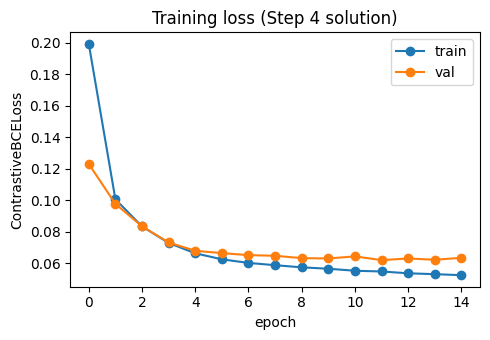

In [12]:
loss_fn_sol = ContrastiveBCELoss(normalization="valid_pairs")
optimizer_sol = torch.optim.Adam(model_solution.parameters(), lr=1e-3)
trainer_sol = Trainer(model_solution, loss_fn_sol, optimizer_sol, device="cpu", amp=False)
history_sol = trainer_sol.fit(train_loader_sol, val_loader=val_loader_sol, epochs=15)
print(history_sol["train_loss"][0], "->", history_sol["train_loss"][-1])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(history_sol["train_loss"], marker="o", label="train")
ax.plot(history_sol["val_loss"], marker="o", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("ContrastiveBCELoss")
ax.set_title("Training loss (Step 4 solution)")
ax.legend()
fig.tight_layout()

### Step 5 solution

In [13]:
val_metrics_sol = trainer_sol.evaluate(val_loader_sol, ks=(1, 3, 5))
val_metrics_sol

{'loss': 0.06349788182160167,
 'hit_at_k': {1: 0.9183168316831684, 3: 0.995049504950495, 5: 1.0},
 'accuracy': 0.9264018691588785,
 'precision': 0.924097074481051,
 'recall': 0.9264018691588785,
 'f1': 0.9250657769510005,
 'roc_auc': 0.9585276439799845,
 'pr_auc': 0.7836260959238683,
 'threshold': 0.88}

### Step 6 solution

In [14]:
model_config_dp_sol = CEModelConfig(
    embedding_dim=embedding_dim,
    center_encoder=center_encoder_cfg,
    context_encoder=context_encoder_cfg,
    scorer=ScorerConfig(name="dot_product", params={}),
)
model_dp_sol = build_model(model_config_dp_sol)
loss_fn_dp_sol = ContrastiveBCELoss(normalization="valid_pairs")
optimizer_dp_sol = torch.optim.Adam(model_dp_sol.parameters(), lr=1e-3)
trainer_dp_sol = Trainer(model_dp_sol, loss_fn_dp_sol, optimizer_dp_sol, device="cpu", amp=False)
history_dp_sol = trainer_dp_sol.fit(train_loader_sol, val_loader=val_loader_sol, epochs=15)
val_metrics_dp_sol = trainer_dp_sol.evaluate(val_loader_sol, ks=(1, 3, 5))
print(f"cosine_temperature pr_auc: {val_metrics_sol['pr_auc']:.4f}")
print(f"dot_product        pr_auc: {val_metrics_dp_sol['pr_auc']:.4f}")

cosine_temperature pr_auc: 0.7836
dot_product        pr_auc: 0.7933
